In [1]:
import pandas as pd 
da=pd.read_csv("MERGED FINAL.csv")
da.head()

,main_name,BY,CD + BY,CD,SW_%,KW_%,LF_%,ST_%,Time,Volume
0,BY + 40% SW + 60% KW,1,0,0,40.0,60.0,0.0,0.0,0.000000,0.000000
1,BY + 40% SW + 60% KW,1,0,0,40.0,60.0,0.0,0.0,0.198553,38.298758
2,BY + 40% SW + 60% KW,1,0,0,40.0,60.0,0.0,0.0,0.201217,38.444227
3,BY + 40% SW + 60% KW,1,0,0,40.0,60.0,0.0,0.0,0.203875,38.589697
4,BY + 40% SW + 60% KW,1,0,0,40.0,60.0,0.0,0.0,0.206527,38.735166


In [2]:
X = da.drop(columns=['main_name','Volume'], axis=1)
Y= da['Volume']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
 )

     fold  test_size        r2  actual_mean  predicted_mean
0  Fold 1       5392  0.998289    64.672857       64.599701
1  Fold 2       5392  0.998008    65.479792       65.507484
Overall 4-fold CV R2: 0.9981


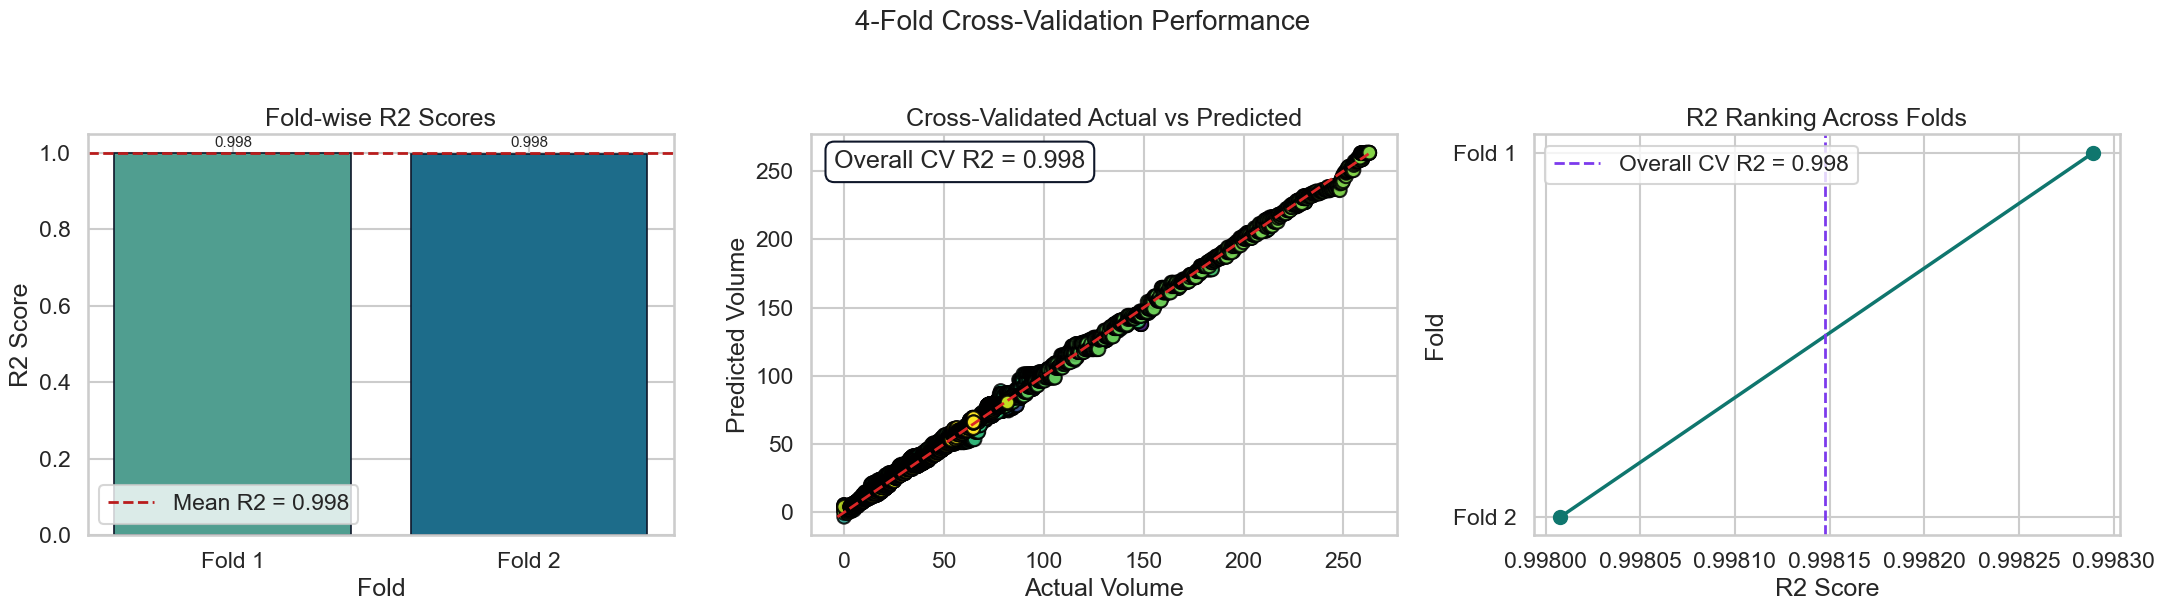

In [18]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid", context="talk")

feature_cols = [col for col in da.columns if col not in ["main_name", "CD", "Volume"]]
target_col = "Volume"
X = da[feature_cols].copy()
y = da[target_col].copy()

kf = KFold(n_splits=2, shuffle=True, random_state=42)
fold_results = []
cv_predictions = np.full(len(da), np.nan)

for fold_number, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42
    )

    model.fit(X_train_fold, y_train_fold)
    y_pred_fold = model.predict(X_test_fold)

    fold_r2 = r2_score(y_test_fold, y_pred_fold)
    cv_predictions[test_idx] = y_pred_fold

    fold_results.append(
        {
            "fold": f"Fold {fold_number}",
            "test_size": len(test_idx),
            "r2": fold_r2,
            "actual_mean": y_test_fold.mean(),
            "predicted_mean": np.mean(y_pred_fold),
        }
    )

cv_results_df = pd.DataFrame(fold_results)
overall_cv_r2 = r2_score(y, cv_predictions)

print(cv_results_df)
print(f"Overall 4-fold CV R2: {overall_cv_r2:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

bar_colors = sns.color_palette("crest", n_colors=len(cv_results_df))
bars = axes[0].bar(
    cv_results_df["fold"],
    cv_results_df["r2"],
    color=bar_colors,
    edgecolor="#0f172a",
    linewidth=1.2
)
axes[0].axhline(cv_results_df["r2"].mean(), color="#b91c1c", linestyle="--", linewidth=2, label=f"Mean R2 = {cv_results_df['r2'].mean():.3f}")
axes[0].set_title("Fold-wise R2 Scores")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("R2 Score")
axes[0].legend(frameon=True)
for bar, value in zip(bars, cv_results_df["r2"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + (0.01 if value >= 0 else -0.03),
        f"{value:.3f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=11
    )

scatter = axes[1].scatter(
    y,
    cv_predictions,
    c=np.arange(len(y)),
    cmap="viridis",
    s=95,
    edgecolor="black",
    alpha=0.85
)
axis_min = min(y.min(), np.nanmin(cv_predictions))
axis_max = max(y.max(), np.nanmax(cv_predictions))
axes[1].plot([axis_min, axis_max], [axis_min, axis_max], "--", color="#dc2626", linewidth=2)
axes[1].set_title("Cross-Validated Actual vs Predicted")
axes[1].set_xlabel("Actual Volume")
axes[1].set_ylabel("Predicted Volume")
axes[1].text(
    0.04,
    0.96,
    f"Overall CV R2 = {overall_cv_r2:.3f}",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#0f172a")
)

r2_sorted = cv_results_df.sort_values("r2", ascending=True).reset_index(drop=True)
axes[2].plot(
    r2_sorted["r2"],
    r2_sorted["fold"],
    marker="o",
    markersize=10,
    linewidth=2.5,
    color="#0f766e"
)
axes[2].axvline(overall_cv_r2, color="#7c3aed", linestyle="--", linewidth=2, label=f"Overall CV R2 = {overall_cv_r2:.3f}")
axes[2].set_title("R2 Ranking Across Folds")
axes[2].set_xlabel("R2 Score")
axes[2].set_ylabel("Fold")
axes[2].legend(frameon=True)

fig.suptitle("4-Fold Cross-Validation Performance", fontsize=20, y=1.03)
fig.tight_layout()
plt.show()

In [11]:
len(da['main_name'].value_counts())

11

                                main_name  n_test_rows   test_r2
0        CD + 68.5% SW + 30% KW + 1.5% LF         1001 -5.367465
1                                 CD + SW          972 -2.912789
2                            CD + BY + SW          999 -2.705555
3            CD + 65% SW + 30% KW + 5% ST          920 -2.159201
4                                 CD + KW          991 -1.559140
5                                 BY + SW         1001 -0.785996
6           CD + 60% SW + 30% KW + 10% ST         1001 -0.403126
7               CD + BY + 70% SW + 30% KW         1001  0.120289
8            CD + 65% SW + 30% KW + 5% LF          954  0.246621
9      CD + BY + 60% SW + 30% KW + 10% ST         1001  0.300284
10       CD + 62.5% SW + 30% KW + 7.5% LF          961  0.395373
11  CD + BY + 68.5% SW + 30% KW + 1.5% ST         1001  0.453470
12                   CD + 70% SW + 30% KW         1001  0.507691
13                   BY + 70% SW + 30% KW         1001  0.587367
14          BY + 60% SW +

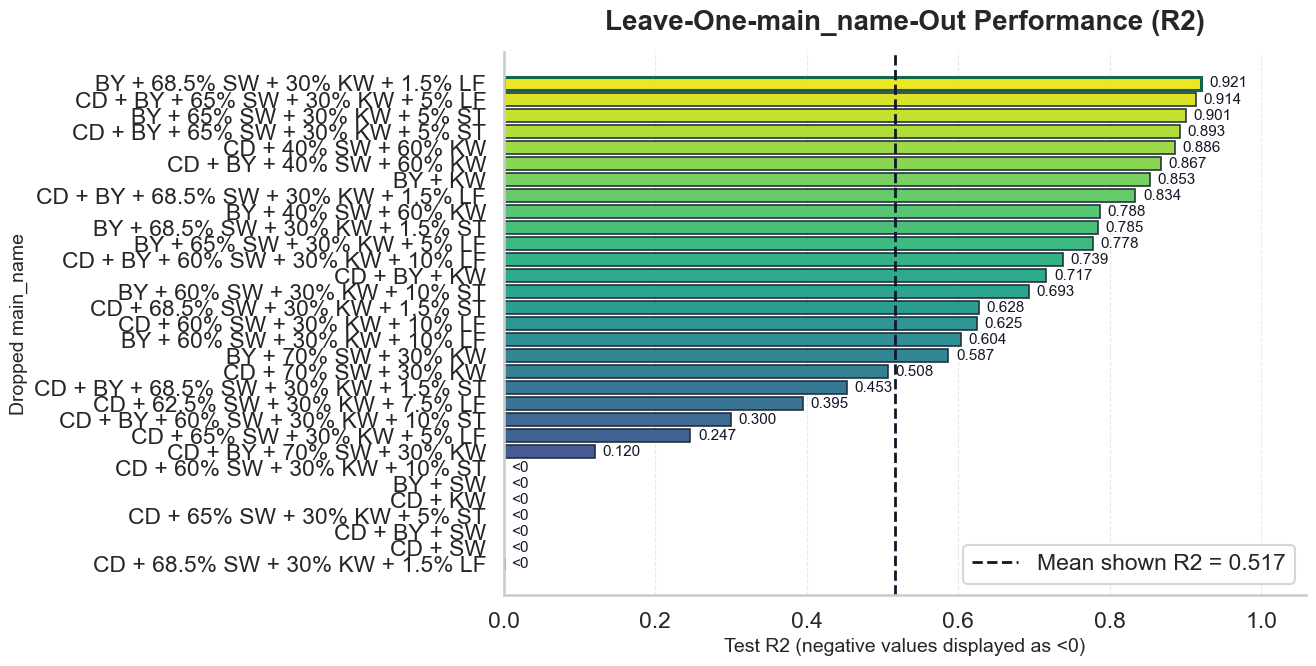

In [3]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

feature_cols = [col for col in da.columns if col not in ["main_name", "CD", "Volume"]]
target_col = "Volume"

main_names = da["main_name"].dropna().unique()
rng = np.random.default_rng(42)
main_names = rng.permutation(main_names)

results = []

for dropped_name in main_names:
    train_mask = da["main_name"] != dropped_name
    test_mask = da["main_name"] == dropped_name

    X_train = da.loc[train_mask, feature_cols]
    y_train = da.loc[train_mask, target_col]
    X_test = da.loc[test_mask, feature_cols]
    y_test = da.loc[test_mask, target_col]

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    test_r2 = r2_score(y_test, y_test_pred) if len(y_test) > 1 else np.nan

    results.append(
        {
            "main_name": dropped_name,
            "n_test_rows": len(y_test),
            "test_r2": test_r2,
        }
    )

results_df = pd.DataFrame(results).sort_values("test_r2", ascending=True).reset_index(drop=True)
print(results_df[["main_name", "n_test_rows", "test_r2"]])

plot_df = results_df.dropna(subset=["test_r2"]).copy()
plot_df["plot_r2"] = plot_df["test_r2"].clip(lower=0)
plot_df["label_r2"] = plot_df["test_r2"].apply(lambda v: "<0" if v < 0 else f"{v:.3f}")

mean_plot_r2 = plot_df["plot_r2"].mean()

fig, ax = plt.subplots(figsize=(13.5, 7))
colors = sns.color_palette("viridis", n_colors=len(plot_df))

bars = ax.barh(
    y=plot_df["main_name"],
    width=plot_df["plot_r2"],
    color=colors,
    edgecolor="#1f2937",
    linewidth=1.2,
    alpha=0.95
)

best_idx = plot_df["test_r2"].idxmax()
worst_idx = plot_df["test_r2"].idxmin()
for i, idx in enumerate(plot_df.index):
    if idx == best_idx:
        bars[i].set_edgecolor("#065f46")
        bars[i].set_linewidth(2.2)
    elif idx == worst_idx:
        bars[i].set_edgecolor("#991b1b")
        bars[i].set_linewidth(2.2)

ax.axvline(mean_plot_r2, color="#0f172a", linestyle="--", linewidth=2, label=f"Mean shown R2 = {mean_plot_r2:.3f}")

for bar, shown_value, label_value in zip(bars, plot_df["plot_r2"], plot_df["label_r2"]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    text_x = x + 0.01 if x > 0 else 0.01
    ax.text(text_x, y, label_value, va="center", ha="left", fontsize=11, color="#111827")

max_x = max(0.05, plot_df["plot_r2"].max() * 1.15)
ax.set_xlim(0, max_x)

ax.set_title("Leave-One-main_name-Out Performance (R2)", fontsize=20, pad=16, weight="bold")
ax.set_xlabel("Test R2 (negative values displayed as <0)", fontsize=14)
ax.set_ylabel("Dropped main_name", fontsize=14)
ax.legend(frameon=True, fancybox=True)
ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.45)
ax.grid(axis="y", visible=False)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

100%|===================| 30697/30802 [02:57<00:00]        

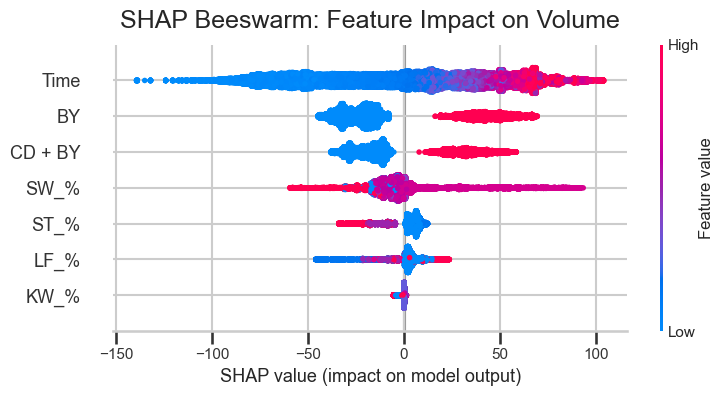

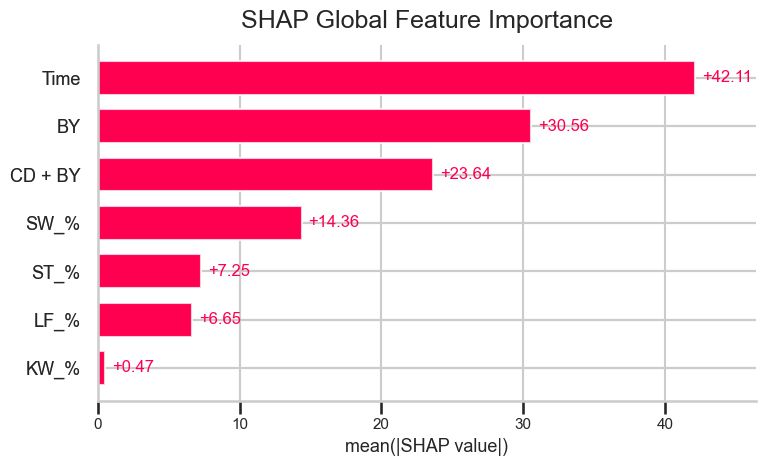

In [4]:
# Train on full dataset, then compute and plot SHAP values
import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

feature_cols = [col for col in da.columns if col not in ["main_name", "CD", "Volume"]]
target_col = "Volume"

X_full = da[feature_cols]
y_full = da[target_col]

full_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42
)
full_model.fit(X_full, y_full)

explainer = shap.Explainer(full_model, X_full)
shap_values = explainer(X_full)

# SHAP beeswarm plot (distribution + direction of impact)
plt.figure(figsize=(12, 7))
shap.plots.beeswarm(shap_values, max_display=len(feature_cols), show=False)
plt.title("SHAP Beeswarm: Feature Impact on Volume", pad=12)
plt.tight_layout()
plt.show()

# SHAP bar plot (global importance)
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=len(feature_cols), show=False)
plt.title("SHAP Global Feature Importance", pad=12)
plt.tight_layout()
plt.show()